In [1]:
import cooler
import pandas as pd
from ggner_3d.boundaries import assign_domain_score, make_tads
from ggner_3d.cm import MCOOL_PATH_DICT_BIOREPS, prepare_view_df
from ggner_3d import plotting
plotting.update_rcparams()

import bioframe as bf
import ptitprince as pt
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import ptitprince as pt
from statannotations.Annotator import Annotator
import numpy as np
import seaborn as sns
from coolpuppy import coolpup

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

window_bp = 500_000
bin_bp = 10_000

samples_oi = ['WT_noUV_r1', 'WT_noUV_r2', 'WT_3h_r1', 'WT_3h_r2', 'XPC_noUV_r1', 'XPC_noUV_r2', 'XPC_3h_r1', 'XPC_3h_r2', 'XPA_noUV_r1', 'XPA_noUV_r2', 'XPA_3h_r1', 'XPA_3h_r2']

clr_ = {
    k: cooler.Cooler(f'{MCOOL_PATH_DICT_BIOREPS[k]}::/resolutions/{bin_bp}') for k in MCOOL_PATH_DICT_BIOREPS.keys() if k in samples_oi
}

In [2]:
insulation_path_merged = '/home/carlos/Clone/ggner-3d/data/insulation'
insulation_path_reps = '/home/carlos/Clone/ggner-3d/data/insulation_reps'

columns_oi = ['chrom', 'start', 'end', 'region', 'is_bad_bin', f'log2_insulation_score_{window_bp}', f'n_valid_pixels_{window_bp}', f'boundary_strength_{window_bp}', f'is_boundary_{window_bp}']

insulation_df = pd.read_csv(f'{insulation_path_merged}/insulation_WTnoUV_{bin_bp}bp.csv')[columns_oi]

In [3]:
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

wtnouv_tads_df = insulation_df.loc[
    insulation_df[f'is_boundary_{window_bp}'] == True,
    ['chrom', 'start', 'end']
]
wtnouv_tads_df = make_tads(
    wtnouv_tads_df,
    maxlen = MAXLEN, minlen=MINLEN
)
print(wtnouv_tads_df.shape)

(2955, 3)


In [4]:
expected_dfs = {
    k:pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/expected_reps/expected_cis_chrom_{k}_res10kb.tsv', sep='\t') for k in clr_.keys() if k in samples_oi
}

In [5]:
tad_strengths = {k: [] for k in clr_.keys() if k in samples_oi}

view_df = prepare_view_df(arm=False)

for sample, clr in clr_.items():
    print(f'Processing {sample}...')
    expected_df = expected_dfs[sample]
    tad_strengths[sample] = assign_domain_score(
        tads_df=wtnouv_tads_df,
        clr=clr_[sample],
        expected=expected_df,
        view_df=view_df,
        resolution=10_000,
        nproc=6,
        clr_weight_name='sweight',
        rescale_flank=rescale_flank,
        rescale_size=rescale_size,
        score_flank=score_flank
    )

Processing WT_noUV_r1...


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 182
INFO:coolpuppy:('chr5', 'chr5'): 177
INFO:coolpuppy:('chr4', 'chr4'): 190
INFO:coolpuppy:('chr3', 'chr3'): 208
INFO:coolpuppy:('chr1', 'chr1'): 252
INFO:coolpuppy:('chr2', 'chr2'): 228
INFO:coolpuppy:('chr9', 'chr9'): 121
INFO:coolpuppy:('chr7', 'chr7'): 146
INFO:coolpuppy:('chr10', 'chr10'): 132
INFO:coolpuppy:('chr8', 'chr8'): 151
INFO:coolpuppy:('chr11', 'chr11'): 157
INFO:coolpuppy:('chr12', 'chr12'): 154
INFO:coolpuppy:('chr13', 'chr13'): 90
INFO:coolpuppy:('chr14', 'chr14'): 103
INFO:coolpuppy:('chr15', 'chr15'): 93
INFO:coolpuppy:('chr17', 'chr17'): 85
INFO:coolpuppy:('chr16', 'chr16'): 69
INFO:coolpuppy:('chr19', 'chr19'): 63
INFO:coolpuppy:('chr21', 'chr21'): 27
INFO:coolpuppy:('chr18', 'chr18'): 73
INFO:coolpuppy:('chr22', 'chr22'): 37
INFO:coolpuppy:('chr20', 'chr20'): 71
INFO:coolpuppy:('chrX', 'chrX'): 133
INFO:coolpuppy:Total number of piled up windows: 252


Processing WT_noUV_r2...


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr5', 'chr5'): 177
INFO:coolpuppy:('chr6', 'chr6'): 182
INFO:coolpuppy:('chr4', 'chr4'): 190
INFO:coolpuppy:('chr3', 'chr3'): 208
INFO:coolpuppy:('chr1', 'chr1'): 252
INFO:coolpuppy:('chr2', 'chr2'): 228
INFO:coolpuppy:('chr9', 'chr9'): 121
INFO:coolpuppy:('chr7', 'chr7'): 146
INFO:coolpuppy:('chr10', 'chr10'): 132
INFO:coolpuppy:('chr11', 'chr11'): 157
INFO:coolpuppy:('chr8', 'chr8'): 151
INFO:coolpuppy:('chr12', 'chr12'): 154
INFO:coolpuppy:('chr13', 'chr13'): 90
INFO:coolpuppy:('chr14', 'chr14'): 103
INFO:coolpuppy:('chr15', 'chr15'): 93
INFO:coolpuppy:('chr17', 'chr17'): 85
INFO:coolpuppy:('chr16', 'chr16'): 69
INFO:coolpuppy:('chr19', 'chr19'): 63
INFO:coolpuppy:('chr18', 'chr18'): 73
INFO:coolpuppy:('chr21', 'chr21'): 27
INFO:coolpuppy:('chr22', 'chr22'): 37
INFO:coolpuppy:('chr20', 'chr20'): 71
INFO:coolpuppy:('chrX', 'chrX'): 133
INFO:coolpuppy:Total number of piled up windows: 252


Processing WT_3h_r1...


...

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 182
INFO:coolpuppy:('chr5', 'chr5'): 177
INFO:coolpuppy:('chr4', 'chr4'): 190
INFO:coolpuppy:('chr3', 'chr3'): 208
INFO:coolpuppy:('chr1', 'chr1'): 252
INFO:coolpuppy:('chr2', 'chr2'): 228
INFO:coolpuppy:('chr9', 'chr9'): 121
INFO:coolpuppy:('chr7', 'chr7'): 146
INFO:coolpuppy:('chr10', 'chr10'): 132
INFO:coolpuppy:('chr11', 'chr11'): 157
INFO:coolpuppy:('chr8', 'chr8'): 151
INFO:coolpuppy:('chr12', 'chr12'): 154
INFO:coolpuppy:('chr13', 'chr13'): 90
INFO:coolpuppy:('chr16', 'chr16'): 69
INFO:coolpuppy:('chr14', 'chr14'): 103
INFO:coolpuppy:('chr15', 'chr15'): 93
INFO:coolpuppy:('chr17', 'chr17'): 85
INFO:coolpuppy:('chr19', 'chr19'): 63
INFO:coolpuppy:('chr18', 'chr18'): 73
INFO:coolpuppy:('chr21', 'chr21'): 27
INFO:coolpuppy:('chr22', 'chr22'): 37
INFO:coolpuppy:('chr20', 'chr20'): 71
INFO:coolpuppy:('chrX', 'chrX'): 133
INFO:coolpuppy:Total number of piled up windows: 252


Processing XPC_3h_r1...


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 182
INFO:coolpuppy:('chr5', 'chr5'): 177
INFO:coolpuppy:('chr4', 'chr4'): 190
INFO:coolpuppy:('chr3', 'chr3'): 208
INFO:coolpuppy:('chr1', 'chr1'): 252
INFO:coolpuppy:('chr2', 'chr2'): 228
INFO:coolpuppy:('chr9', 'chr9'): 121
INFO:coolpuppy:('chr10', 'chr10'): 132
INFO:coolpuppy:('chr7', 'chr7'): 146
INFO:coolpuppy:('chr11', 'chr11'): 157
INFO:coolpuppy:('chr8', 'chr8'): 151
INFO:coolpuppy:('chr12', 'chr12'): 154
INFO:coolpuppy:('chr13', 'chr13'): 90
INFO:coolpuppy:('chr16', 'chr16'): 69
INFO:coolpuppy:('chr14', 'chr14'): 103
INFO:coolpuppy:('chr15', 'chr15'): 93
INFO:coolpuppy:('chr19', 'chr19'): 63
INFO:coolpuppy:('chr17', 'chr17'): 85
INFO:coolpuppy:('chr18', 'chr18'): 73
INFO:coolpuppy:('chr21', 'chr21'): 27
INFO:coolpuppy:('chr22', 'chr22'): 37
INFO:coolpuppy:('chr20', 'chr20'): 71
INFO:coolpuppy:('chrX', 'chrX'): 133
INFO:coolpuppy:Total number of piled up windows: 252


Processing XPC_3h_r2...


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 182
INFO:coolpuppy:('chr5', 'chr5'): 177
INFO:coolpuppy:('chr4', 'chr4'): 190
INFO:coolpuppy:('chr3', 'chr3'): 208
INFO:coolpuppy:('chr1', 'chr1'): 252
INFO:coolpuppy:('chr2', 'chr2'): 228
INFO:coolpuppy:('chr9', 'chr9'): 121
INFO:coolpuppy:('chr7', 'chr7'): 146
INFO:coolpuppy:('chr10', 'chr10'): 132
INFO:coolpuppy:('chr11', 'chr11'): 157
INFO:coolpuppy:('chr8', 'chr8'): 151
INFO:coolpuppy:('chr12', 'chr12'): 154
INFO:coolpuppy:('chr13', 'chr13'): 90
INFO:coolpuppy:('chr14', 'chr14'): 103
INFO:coolpuppy:('chr16', 'chr16'): 69
INFO:coolpuppy:('chr15', 'chr15'): 93
INFO:coolpuppy:('chr19', 'chr19'): 63
INFO:coolpuppy:('chr17', 'chr17'): 85
INFO:coolpuppy:('chr18', 'chr18'): 73
INFO:coolpuppy:('chr21', 'chr21'): 27
INFO:coolpuppy:('chr22', 'chr22'): 37
INFO:coolpuppy:('chr20', 'chr20'): 71
INFO:coolpuppy:('chrX', 'chrX'): 133
INFO:coolpuppy:Total number of piled up windows: 252


In [6]:
plot_df = {
    'sample': [],
    'domain_score': []
}

for k,v in tad_strengths.items():
    current_df = v.copy()

    current_df = current_df[np.isfinite(current_df['domain_score'])]
    print(f'{k}: {current_df["domain_score"].mean():.4f} ± {current_df["domain_score"].std():.4f}, n={current_df.shape[0]}')
    plot_df['sample'].extend([k] * current_df.shape[0])
    plot_df['domain_score'].extend(current_df['domain_score'].to_list())

plot_df = pd.DataFrame(plot_df)

WT_noUV_r1: 1.5476 ± 0.4163, n=2942
WT_noUV_r2: 1.5424 ± 0.4204, n=2942
WT_3h_r1: 1.5773 ± 0.4799, n=2942
WT_3h_r2: 1.5906 ± 0.4773, n=2942
XPA_noUV_r1: 1.5005 ± 0.4224, n=2942
XPA_noUV_r2: 1.5046 ± 0.4055, n=2942
XPA_3h_r1: 1.5220 ± 0.4438, n=2942
XPA_3h_r2: 1.5110 ± 0.4335, n=2942
XPC_noUV_r1: 1.6571 ± 0.4933, n=2942
XPC_noUV_r2: 1.6434 ± 0.4805, n=2942
XPC_3h_r1: 1.6807 ± 0.5416, n=2942
XPC_3h_r2: 1.6740 ± 0.5342, n=2942


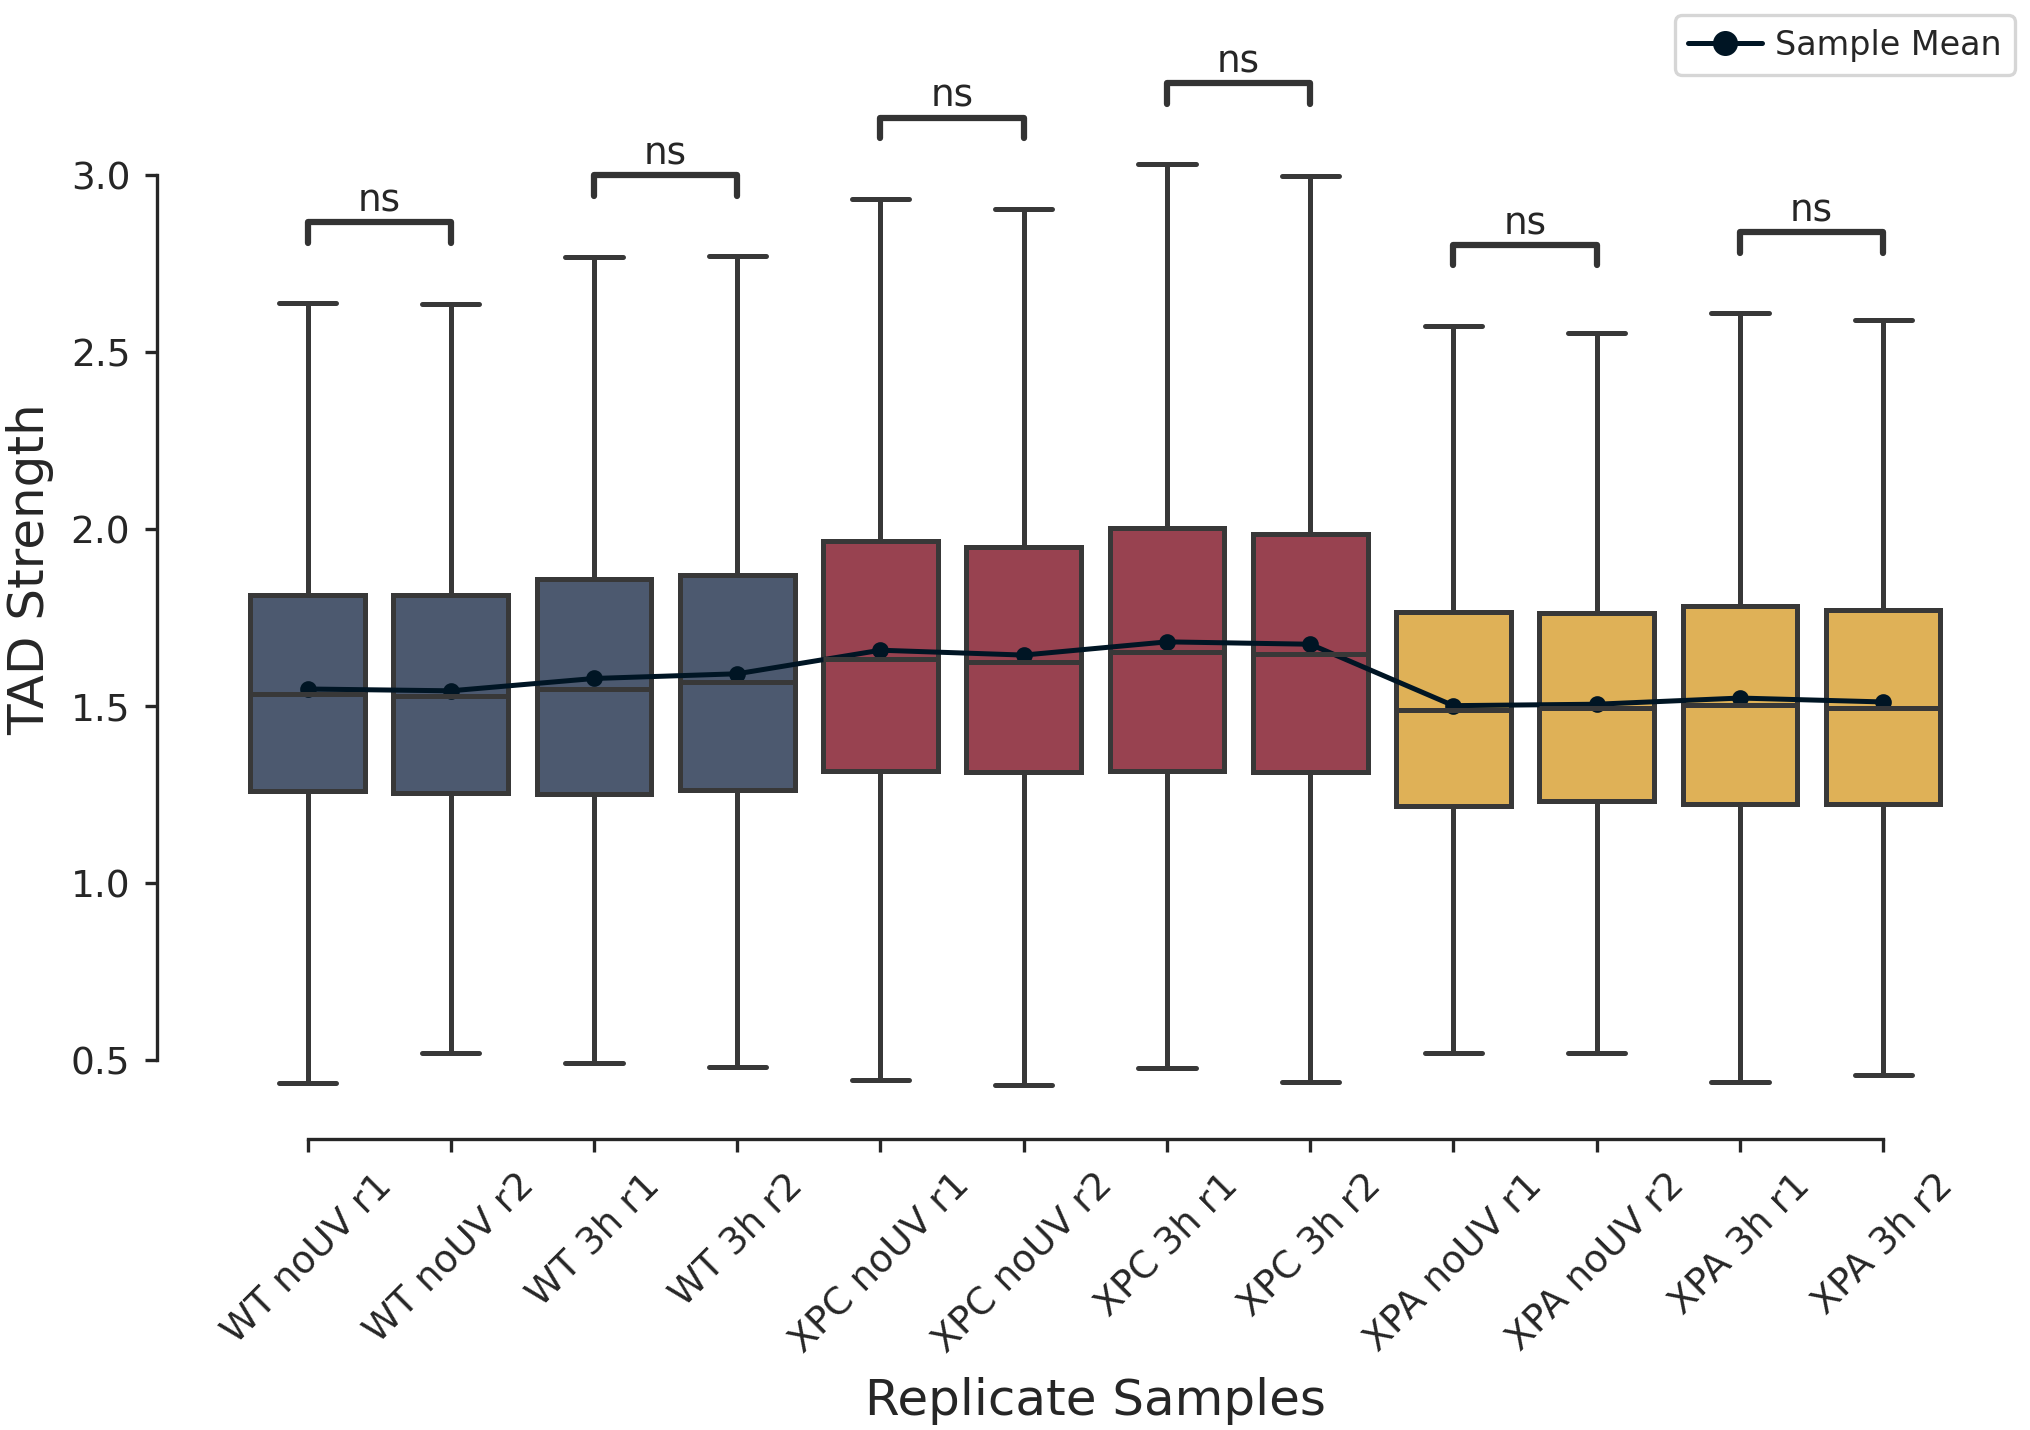

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

# -----------------------
# plot config
# -----------------------
pal = [plotting.COLORS[0]] * 4 + [plotting.COLORS[1]] * 4 + [plotting.COLORS[2]] * 4
dx = "sample"
dy = "domain_score"

# IMPORTANT: stable category order for plot + statannotations
order = [s for s in samples_oi]

# -----------------------
# boxplot
# -----------------------
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=plot_df,
    x=dx,
    y=dy,
    order=order,
    palette=pal,
    ax=ax,
    showfliers=False,
    linewidth=1.2,
)

# (optional) overlay points
# sns.stripplot(
#     data=plot_df, x=dx, y=dy, order=order, ax=ax,
#     color="black", size=2, alpha=0.35, jitter=0.25
# )

ax.set_ylabel("TAD Strength")
ax.set_xlabel("")

# add n to tick labels (optional; currently keeps just sample name)
xticklabels = []
for sample in order:
    n_points = plot_df.loc[plot_df[dx] == sample, dy].shape[0]
    xticklabels.append(f"{sample.replace('_', ' ')}")  # or f"{sample}\n(n={n_points})"

ax.set_xticks(range(len(order)))
ax.set_xticklabels(xticklabels)

# -----------------------
# statannotations
# -----------------------
# Example: your explicit pairs
pairs = [(order[0], order[1]), (order[2], order[3]), (order[4], order[5]), (order[6], order[7]), (order[8], order[9]), (order[10], order[11])]

annot = Annotator(
    ax,
    pairs,
    data=plot_df,
    x=dx,
    y=dy,
    order=order,
)

annot.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    verbose=0,
)

annot.apply_and_annotate()

# -----------------------
# mean connector line + legend entry
# -----------------------
means = plot_df.groupby(dx)[dy].mean().reindex(order)
ax.plot(range(len(order)), means.values, color="#001524", linestyle="-", marker="o", markersize=3)
ax.plot([], [], color="#001524", linestyle="-", marker="o", markersize=5, label="Sample Mean")

# rotate x tick labels (do this near the end so nothing resets it)
ax.tick_params(axis="x", labelrotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")

ax.legend()
ax.set_xlabel("Replicate Samples")
plotting.despine(ax)
plt.tight_layout()

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/domain_strength_500Kb_replicates_boxplot.svg")
plt.show()